# Analysis of Airline1.csv

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from typing import cast
from matplotlib.container import BarContainer


In [2]:
df = pd.read_csv('Airline1.csv')

In [3]:
df[df['Source'].isnull()]

,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10660,10661,Vistara,21-03-2019,NaN,NaN,NaN,21:10,19-03-2026 00:05,2h 55m,non-stop,No info,NaN
10661,10662,Air India,09-05-2019,NaN,NaN,NaN,13:00,19:15,6h 15m,1 stop,No info,NaN


In [4]:
df.fillna({'Source': df['Source'].mode()[0]}, inplace=True)

In [5]:
df[df['Destination'].isnull()]
df.fillna({'Destination': df['Destination'].mode()[0]}, inplace=True)

In [6]:
df[df['Route'].isnull()]
df.fillna({'Route': df['Route'].mode()[0]}, inplace=True)

In [7]:
df[df['Price'].isnull()]
df.fillna({'Price': df['Price'].mean()}, inplace=True)

In [8]:
df[df.duplicated()]

,ID,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
10683,10678,SpiceJet,21-05-2019,Banglore,Delhi,BLR ? DEL,05:55,08:35,2h 40m,non-stop,No check-in baggage included,3257.0
10684,10679,Air Asia,09-04-2019,Kolkata,Banglore,CCU ? BLR,19:55,22:25,2h 30m,non-stop,No info,4107.0
10685,10680,Air India,27-04-2019,Kolkata,Banglore,CCU ? BLR,20:45,23:20,2h 35m,non-stop,No info,4145.0
10686,10681,Jet Airways,27-04-2019,Banglore,Delhi,BLR ? DEL,08:20,11:20,3h,non-stop,No info,7229.0
10687,10682,Vistara,01-03-2019,Banglore,New Delhi,BLR ? DEL,11:30,14:10,2h 40m,non-stop,No info,12648.0
10688,10683,Air India,09-05-2019,Delhi,Cochin,DEL ? GOI ? BOM ? COK,10:55,19:15,8h 20m,2 stops,No info,11753.0


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df['Airline'].value_counts()

Airline
Jet Airways                          3849
IndiGo                               2053
Air India                            1752
Multiple carriers                    1196
SpiceJet                              818
Vistara                               479
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64

In [11]:
df['Source'].value_counts()

Source
Delhi       4538
Kolkata     2871
Banglore    2196
Mumbai       697
Chennai      381
Name: count, dtype: int64

In [12]:
df['Destination'].value_counts()

Destination
Cochin       4538
Banglore     2871
Delhi        1265
New Delhi     931
Hyderabad     697
Kolkata       381
Name: count, dtype: int64

In [13]:
df['Total_Stops'].isnull().sum()
df.fillna({'Total_Stops': df['Total_Stops'].mode()[0]}, inplace=True)

In [14]:
df['Destination']=df['Destination'].replace('New Delhi', 'Delhi')

In [15]:
df['Total_Stops'].value_counts()

Total_Stops
1 stop      5626
non-stop    3491
2 stops     1520
3 stops       45
4 stops        1
Name: count, dtype: int64

In [16]:
df['Arrival_Time'].value_counts()

Arrival_Time
19:00               423
21:00               360
19:15               333
16:10               154
12:35               122
                   ... 
02-06-2026 00:25      1
13-03-2026 08:55      1
19-05-2026 11:05      1
22-05-2026 12:30      1
13-03-2026 21:20      1
Name: count, Length: 1343, dtype: int64

In [17]:
df.columns

Index(['ID', 'Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

# Stats Analysis

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10683 entries, 0 to 10682
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ID               10683 non-null  int64  
 1   Airline          10683 non-null  object 
 2   Date_of_Journey  10683 non-null  object 
 3   Source           10683 non-null  object 
 4   Destination      10683 non-null  object 
 5   Route            10683 non-null  object 
 6   Dep_Time         10683 non-null  object 
 7   Arrival_Time     10683 non-null  object 
 8   Duration         10683 non-null  object 
 9   Total_Stops      10683 non-null  object 
 10  Additional_Info  10683 non-null  object 
 11  Price            10683 non-null  float64
dtypes: float64(1), int64(1), object(10)
memory usage: 1.1+ MB


In [19]:
df.describe()

,ID,Price
count,10683.000000,10683.000000
mean,5342.000000,9087.219176
std,3084.060797,4611.065933
min,1.000000,1759.000000
25%,2671.500000,5277.000000
50%,5342.000000,8372.000000
75%,8012.500000,12373.000000
max,10683.000000,79512.000000


# Graphs

In [20]:
aircount = df.groupby('Airline')['Airline'].count().sort_values(ascending=True)

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11],
 [Text(0, 0, 'Trujet'),
  Text(1, 0, 'Vistara Premium economy'),
  Text(2, 0, 'Jet Airways Business'),
  Text(3, 0, 'Multiple carriers Premium economy'),
  Text(4, 0, 'GoAir'),
  Text(5, 0, 'Air Asia'),
  Text(6, 0, 'Vistara'),
  Text(7, 0, 'SpiceJet'),
  Text(8, 0, 'Multiple carriers'),
  Text(9, 0, 'Air India'),
  Text(10, 0, 'IndiGo'),
  Text(11, 0, 'Jet Airways')])

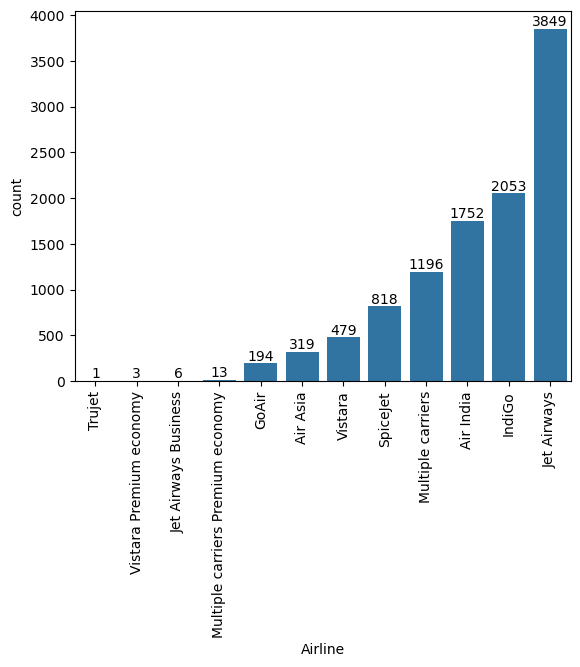

In [21]:
# Distribution of Airlines
ax= sns.countplot(x=df['Airline'], order=aircount.index)
ax.bar_label(cast(BarContainer, ax.containers[0]))
plt.xticks(rotation=90)

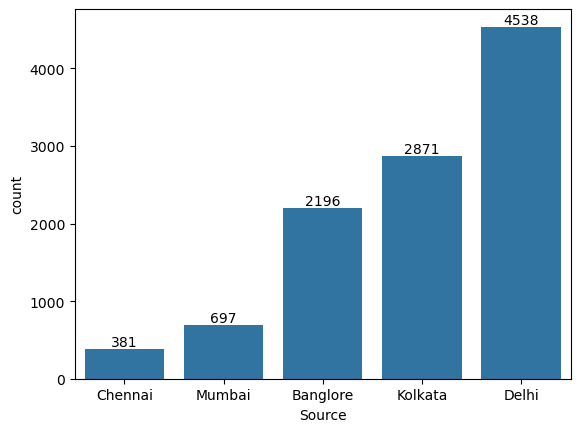

In [22]:
# Distribution of Source
sourcecount = df.groupby('Source')['Source'].count().sort_values(ascending=True)

ax= sns.countplot(x=df['Source'], order=sourcecount.index)
ax.bar_label(cast(BarContainer, ax.containers[0]))
plt.savefig('presentation/1_Source_Distribution.png', dpi=300, bbox_inches='tight')


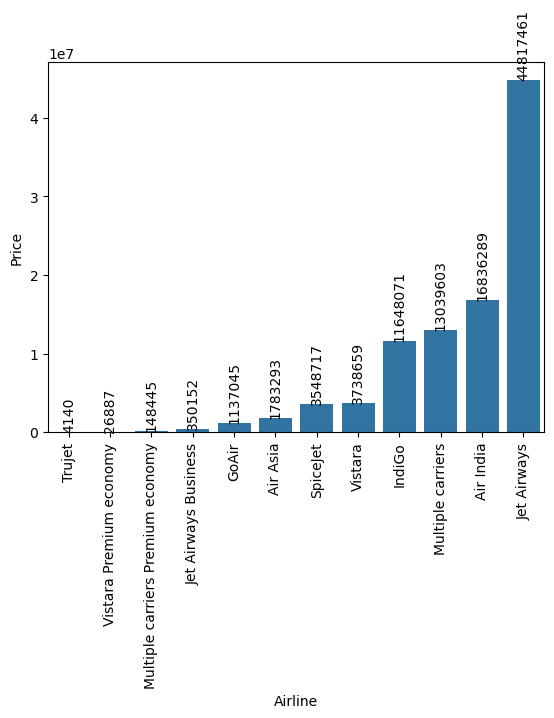

In [23]:
# Price Distribution against Airlines
airline_price = df.groupby('Airline')['Price'].sum().sort_values()
ax = sns.barplot(x='Airline', y='Price', data=df, estimator='sum',order=airline_price.index,errorbar=None)
ax.bar_label(ax.containers[0],rotation=90,fmt='%.0f')  
plt.xticks(rotation=90)
plt.savefig('presentation/2_Price_Distribution_Airline.png', dpi=300, bbox_inches='tight')

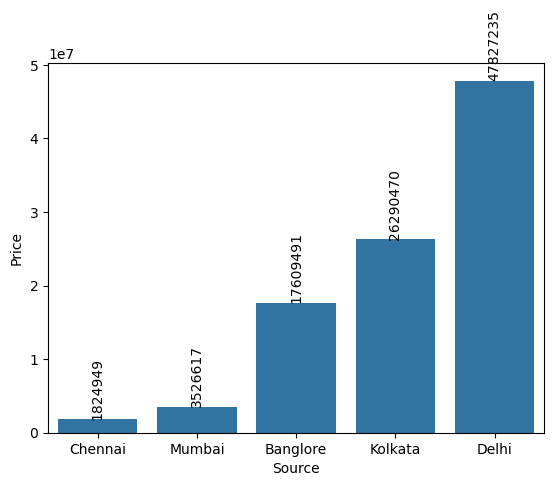

In [24]:
# Distribution of Price against Source
source_price = df.groupby('Source')['Price'].sum().sort_values(ascending=True)
ax= sns.barplot(x='Source', y='Price', data=df, estimator='sum',order=source_price.index,errorbar=None)
ax.bar_label(ax.containers[0],rotation=90,fmt='%.0f')
plt.savefig('presentation/3_Price_Distribution_Source.png', dpi=300, bbox_inches='tight')


In [25]:
# Distribution of Stops against Prices
tsdf = df.groupby('Total_Stops')['Price'].agg(['mean','count']).sort_values(by='mean',ascending=True)

C:\Users\bhato\AppData\Local\Temp\ipykernel_28084\1227321710.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=tsdf.index, y=tsdf['mean'], palette='Blues_d')


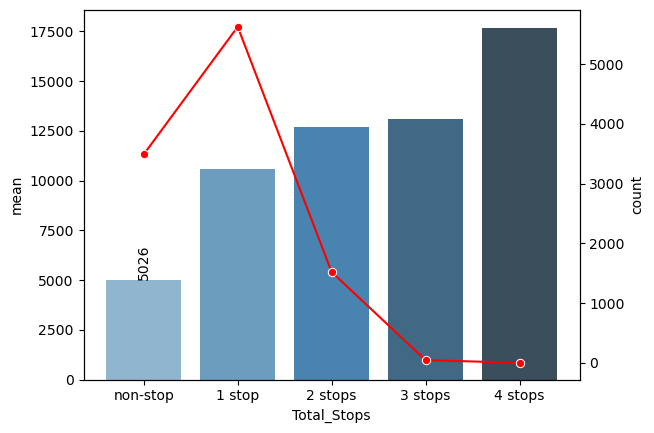

In [26]:
ax = sns.barplot(x=tsdf.index, y=tsdf['mean'], palette='Blues_d')

ax.twinx()
ax2 = sns.lineplot(x=tsdf.index, y=tsdf['count'], color='red', marker='o',errorbar=None)
ax.bar_label(cast(BarContainer, ax.containers[0]),rotation=90,fmt='%.0f')
plt.savefig('presentation/4_Avg_Price_Count_Stops.png', dpi=300, bbox_inches='tight')
plt.show()

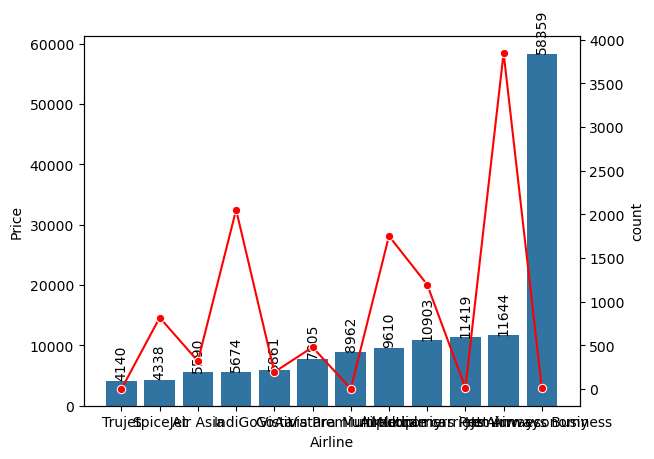

In [27]:
# Avg Price count vs airline
avg_price_airline = df.groupby('Airline')['Price'].agg(['mean','count']).sort_values(by='mean',ascending=True)
ax = sns.barplot(x='Airline', y='Price', data=df, estimator='mean',order=avg_price_airline.index,errorbar=None)
ax.bar_label(cast(BarContainer, ax.containers[0]),rotation=90,
fmt='%.0f')
ax.twinx()
ax2 = sns.lineplot(x=avg_price_airline.index, y=avg_price_airline['count'], color='red', marker='o',errorbar=None)
plt.savefig('presentation/5_Avg_Price_Count_Airline.png', dpi=300, bbox_inches='tight')

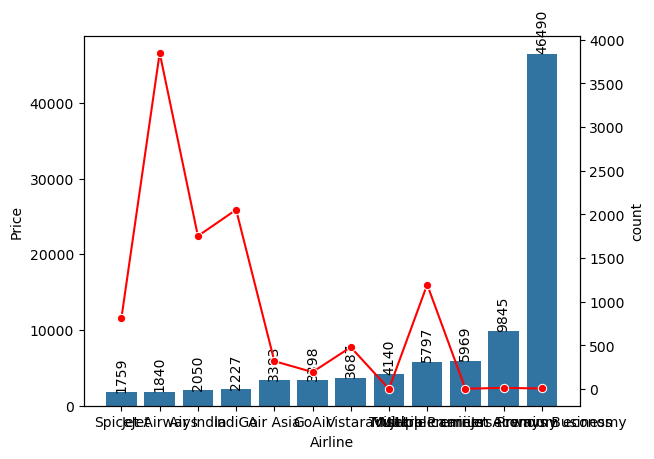

In [28]:
# min price vs count  for airline
min_price_airline = df.groupby('Airline')['Price'].agg(['min','count']).sort_values(by='min',ascending=True)
ax = sns.barplot(x='Airline', y='Price', data=df, estimator='min',order=min_price_airline.index,errorbar=None)
ax.bar_label(ax.containers[0],rotation=90,
fmt='%.0f')
ax.twinx()
ax2 = sns.lineplot(x=min_price_airline.index, y=min_price_airline['count'], color='red', marker='o')
plt.savefig('presentation/6_Min_Price_Count_Airline.png', dpi=300, bbox_inches='tight')

In [29]:
df['Sector'] = df['Source'] + '-' + df['Destination']

In [30]:
sector_df = df.groupby('Sector')['Price'].agg(['mean']).sort_values(by='mean',ascending=True)
sector_df 

,mean
Sector,
Chennai-Kolkata,4789.892388
Mumbai-Hyderabad,5059.708752
Banglore-Delhi,8018.893898
Kolkata-Banglore,9157.251882
Delhi-Cochin,10539.276181


In [31]:
stops_df = df[df['Total_Stops']=='non-stop']
sector_df = stops_df.groupby('Sector')['Price'].agg(['mean']).sort_values(by='mean',ascending=True)
sector_df

,mean
Sector,
Mumbai-Hyderabad,3932.809984
Kolkata-Banglore,4556.055249
Chennai-Kolkata,4789.892388
Banglore-Delhi,5561.555126
Delhi-Cochin,6328.762402


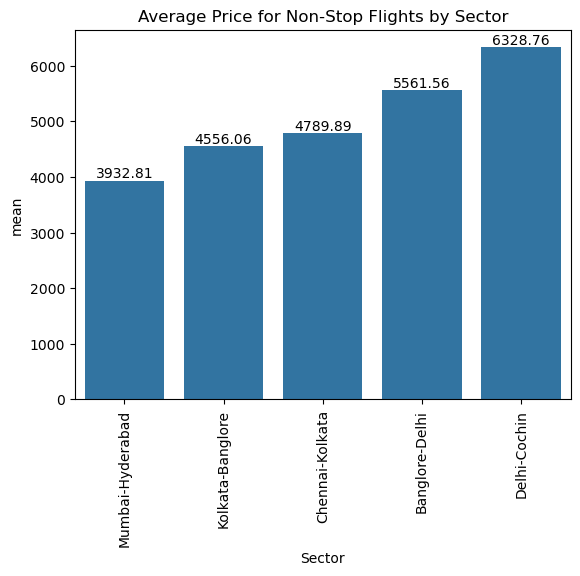

In [32]:
ax = sns.barplot(x=sector_df.index, y='mean', data=sector_df)
ax.bar_label(cast(BarContainer,ax.containers[0]), fmt='%.2f')
plt.xticks(rotation=90)
plt.title('Average Price for Non-Stop Flights by Sector')
plt.savefig('presentation/7_Average_Price_NonStop_Flights_by_Sector.png', dpi=300, bbox_inches='tight')
plt.show()

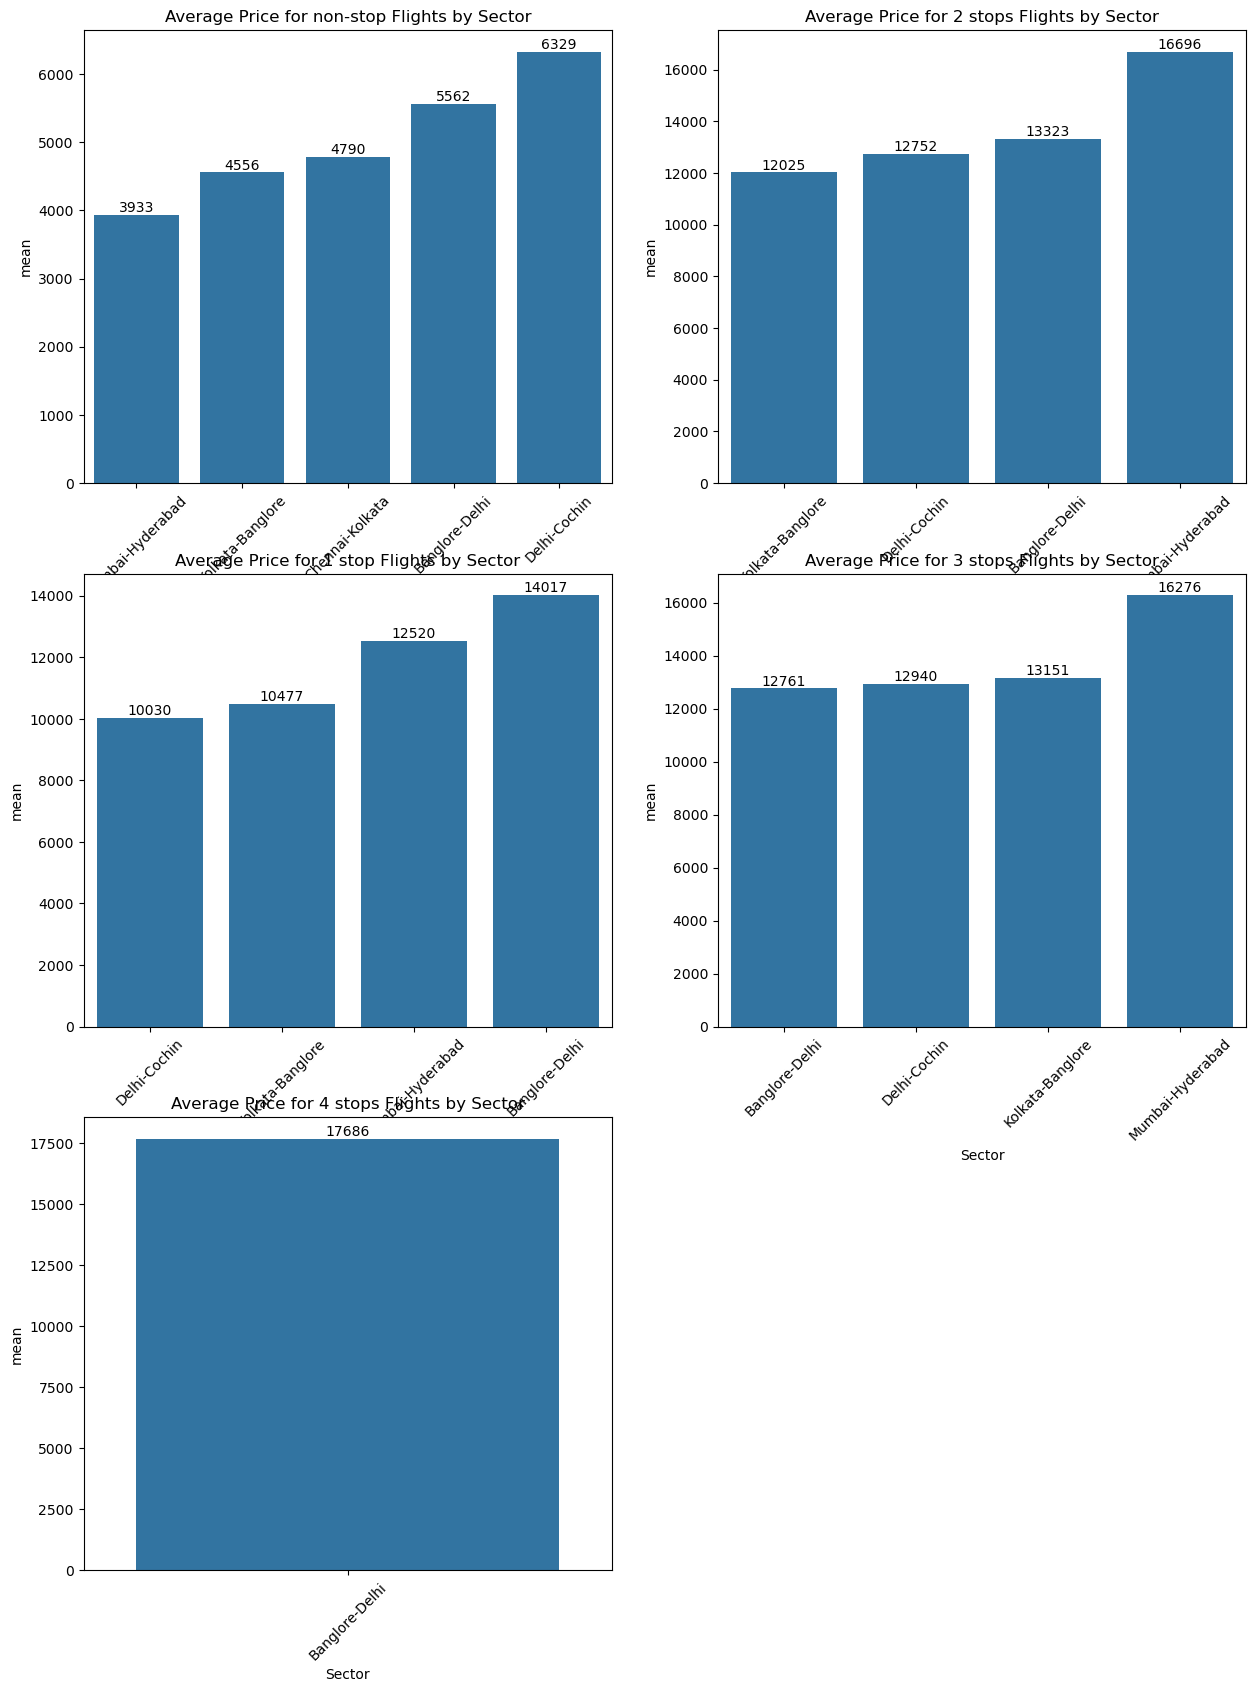

In [33]:
list_stops = list(df['Total_Stops'].unique())
plt.figure(figsize=(15,20))
for i,value in enumerate(list_stops):
    stops_df = df[df['Total_Stops']==value]
    sector_df = stops_df.groupby('Sector')['Price'].agg(['mean']).sort_values(by='mean',ascending=True)
    plt.subplot(3,2,i+1)
    ax = sns.barplot(x=sector_df.index, y='mean', data=sector_df)
    ax.bar_label(ax.containers[0], fmt='%.0f')
    plt.xticks(rotation=45)
    plt.title(f'Average Price for {value} Flights by Sector')
plt.savefig('presentation/8_Average_Price_by_Sector.png', dpi=300, bbox_inches='tight')
plt.show()
